In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import datetime as dt
import re
from sklearn.model_selection import train_test_split, RepeatedKFold, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, ConfusionMatrixDisplay
from patsy import dmatrix

# **1.1. ***sf_crime*** function.**

In [19]:
def sf_crime(full=False, 
             train=True,
             split_seed=12345, 
             encoding=False, 
             datetime_index=True):
    
    path_to_file = '/Users/nancyxu/Desktop/san_fransisco_crime_train.csv'
    X = pd.read_csv(path_to_file, header=0)

    ###########################
    ### Some data cleansing ###
    ###########################
    
    X.columns = X.columns.str.strip().str.lower() 
    X = X.rename(columns={'dates': 'date_time'})
    X = X.drop(columns=['descript', 'resolution'])
    
    # String data cleaning.
    fun_dct = {'category': lambda x: x.strip(), 'pddistrict': lambda x: x.strip()}
    X[['category', 'pddistrict']] = X.transform(fun_dct)
    
    slicing = X['address'].str.contains('/') & (~X['address'].str.contains(' / '))
    X.loc[slicing, 'address'] = X.loc[slicing, 'address'].str.replace('/', '').str.strip()
    
    # Discarding unreliable data (very few rows)
    X = X.loc[X['x'] < -122, :]

    ###########################
    ### Feature engineering ###
    ###########################

    # Handling date&time data
    X['date_time'] = pd.to_datetime(X.date_time) # Encoding 'date_time' as a datetime feature.
    X['year'] = X.date_time.dt.year
    X['month'] = X.date_time.dt.month
    X['day'] = X.date_time.dt.day
    X['hour'] = X.date_time.dt.hour
    X['minute'] = X.date_time.dt.minute
    X['second'] = X.date_time.dt.second
    X['dt_numeric'] = (X.date_time - pd.to_datetime('2003-01-06 00:01:00')).dt.total_seconds()
    X['day_of_week'] = X.date_time.dt.weekday
    X['days_in_month'] = X.date_time.dt.days_in_month
    X['day_of_year'] = X.date_time.dt.day_of_year
    X['week_of_year'] = X.date_time.dt.isocalendar().week
                
    # Parsing address

    #########################
    # parse into block, street_1, and street_2 (street_2 = none if not intersection)
    mask_int = X['address'].str.contains(' / ', na=False)

    # intersection addresses 
    int_ads = X.loc[mask_int, 'address'].str.split(' / ', n=1, expand=True)
    X.loc[mask_int, 'street_1'] = int_ads[0].str.strip().values
    X.loc[mask_int, 'street_2'] = int_ads[1].str.strip().values
    X.loc[mask_int, 'block'] = None

    # block address
    blk_ads = X.loc[~mask_int, 'address']

    split_parts = blk_ads.str.split('Block of', n=1, expand=True)

    X.loc[~mask_int, 'block']    = pd.to_numeric(split_parts[0].str.strip(), errors='coerce')
    X.loc[~mask_int, 'street_1'] = split_parts[1].str.strip().values
    X.loc[~mask_int, 'street_2'] = None

    # dummy predictor =1 if crime occurred at intersection 
    X['intersection'] = mask_int.astype('int8')
    #########################

    # Encoding of categorical variables.
    if (encoding == True):

        # Encoding block, street_1, street_2

        #########################
        # numerically encode street_1 and street_2 using dictionary
        all_streets = pd.concat([X['street_1'].dropna(), X['street_2'].dropna()]).unique()
        street_dict = {s:i for i, s in enumerate(sorted(all_streets))}
        X['street_1'] = X['street_1'].map(street_dict)
        X['street_2'] = X['street_2'].map(street_dict)
        X['street_1'] = X['street_1'].fillna(0)
        X['street_2'] = X['street_2'].fillna(0)
        X['block'] = pd.to_numeric(X['block'], errors='coerce')
        #########################

        # Controlling the type of certain features.
        features = ['minute', 'second', 'hour', 'day', 'month', 'day_of_week', 'days_in_month', 'week_of_year']
        X[features] = X[features].astype('int8')

        features = ['street_1', 'street_2', 'day_of_year', 'year']
        X[features] = X[features].astype('int16')

    # Setting date_time as row-index.
    if (datetime_index == True):
        X = X.set_index(keys='date_time', drop=False)
        # X.index = X['date_time']
        X.index.name = 'key1'

    cols_to_drop = ['dayofweek', 'days_in_month', 'second']
    X = X.drop(columns=cols_to_drop)    

    if (full == True):
        X = X.sort_values(by=['date_time'])
        return X
    
    else:
        y = X['category']
        X_train, X_test = train_test_split(X, test_size=.4, random_state=split_seed, stratify=y)
        
        if (train == True):
            X_train = X_train.sort_values(by=['date_time'])
            return X_train

        else:
            X_test = X_test.sort_values(by=['date_time'])
            return X_test

In [20]:
sf_crime(train=True, encoding=False)[['date_time', 'category', 'pddistrict','address', 'block', 'street_1','street_2', 'intersection']].head(10)

,date_time,category,pddistrict,address,block,street_1,street_2,intersection
key1,,,,,,,,
2003-01-06 00:01:00,2003-01-06 00:01:00,FORGERY/COUNTERFEITING,BAYVIEW,1800 Block of NEWCOMB AV,1800.0,NEWCOMB AV,NaN,0
2003-01-06 00:15:00,2003-01-06 00:15:00,ROBBERY,TARAVAL,FARALLONES ST / CAPITOL AV,None,FARALLONES ST,CAPITOL AV,1
2003-01-06 00:20:00,2003-01-06 00:20:00,ASSAULT,BAYVIEW,1500 Block of SHAFTER AV,1500.0,SHAFTER AV,NaN,0
2003-01-06 00:20:00,2003-01-06 00:20:00,OTHER OFFENSES,BAYVIEW,1500 Block of SHAFTER AV,1500.0,SHAFTER AV,NaN,0
2003-01-06 00:31:00,2003-01-06 00:31:00,OTHER OFFENSES,RICHMOND,CLEMENT ST / 14TH AV,None,CLEMENT ST,14TH AV,1
2003-01-06 00:33:00,2003-01-06 00:33:00,ASSAULT,MISSION,2800 Block of FOLSOM ST,2800.0,FOLSOM ST,NaN,0
2003-01-06 00:40:00,2003-01-06 00:40:00,OTHER OFFENSES,NORTHERN,POLK ST / CALIFORNIA ST,None,POLK ST,CALIFORNIA ST,1
2003-01-06 00:42:00,2003-01-06 00:42:00,WARRANTS,TENDERLOIN,TAYLOR ST / GEARY ST,None,TAYLOR ST,GEARY ST,1
2003-01-06 00:55:00,2003-01-06 00:55:00,LARCENY/THEFT,NORTHERN,1300 Block of WEBSTER ST,1300.0,WEBSTER ST,NaN,0


In [21]:
sf_crime(train=True, encoding=True).info()

<class 'pandas.DataFrame'>
DatetimeIndex: 526789 entries, 2003-01-06 00:01:00 to 2015-05-13 23:33:00
Data columns (total 19 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   date_time     526789 non-null  datetime64[us]
 1   category      526789 non-null  str           
 2   pddistrict    526789 non-null  str           
 3   address       526789 non-null  str           
 4   x             526789 non-null  float64       
 5   y             526789 non-null  float64       
 6   year          526789 non-null  int16         
 7   month         526789 non-null  int8          
 8   day           526789 non-null  int8          
 9   hour          526789 non-null  int8          
 10  minute        526789 non-null  int8          
 11  dt_numeric    526789 non-null  float64       
 12  day_of_week   526789 non-null  int8          
 13  day_of_year   526789 non-null  int16         
 14  week_of_year  526789 non-null  int8          

### **1.2. ***data preprocessing*** function.**

In [3]:
def data_preprocessing(X_train, 
                       X_test, 
                       y_train, 
                       y_test, 
                       selected_predictors=[],
                       one_hot_encoding=False,
                       drop_first=False,
                       full_preprocessing=True,
                       use_interaction=False,
                       use_pca=False,
                       pcs=[],
                       dataframe_format=False):

    # Storing the original indexing.
    X_train_index = X_train.index
    X_test_index = X_test.index
    
    # Output label encoding.
    label_enc = LabelEncoder()
    label_enc.fit(y_train)
    y_train = label_enc.transform(y_train)
    y_test = label_enc.transform(y_test)
    y_train = y_train.astype('int8')
    y_test = y_test.astype('int8')

    # Dropping predictors.
    slicing = ['date_time', 'address']
    X_train = X_train.drop(columns=slicing)
    X_test = X_test.drop(columns=slicing)

    # Encoding of categorical predictors.
    X_train['block'] = np.where(X_train['block'].notna(), X_train['block']/100 + 1, 0)
    X_test['block'] = np.where(X_test['block'].notna(), X_test['block']/100 + 1, 0)
    
    from warnings import filterwarnings
    filterwarnings("ignore", message=".*These unknown categories will be encoded as all zeros.*")
    
    # Numerical encoding of categorical predictors.
    if (one_hot_encoding == True):
        categorical_enc = OneHotEncoder(sparse_output=False,
                                        handle_unknown='ignore',
                                        drop='first' if (drop_first == True) else None,
                                        dtype='int8')
    else: 
        categorical_enc = OrdinalEncoder(handle_unknown='use_encoded_value', 
                                         unknown_value=np.nan, dtype='float64')

    categorical_enc.fit(X_train[['pddistrict']])
    X_train[categorical_enc.get_feature_names_out()] = categorical_enc.transform(X_train[['pddistrict']])
    X_test[categorical_enc.get_feature_names_out()] = categorical_enc.transform(X_test[['pddistrict']])

    if (one_hot_encoding == True):
        X_train = X_train.drop(columns=['pddistrict'])
        X_test = X_test.drop(columns=['pddistrict'])

        if (use_interaction == True):
        
        #########################
            pddistrict_cols = [c for c in X_train.columns if c.startswith('pddistrict_')]
            for col in pddistrict_cols:
                interact_col = col + ':intersection'
                X_train[interact_col] = (X_train[col] * X_train['intersection']).astype('int8')
                X_test[interact_col]  = (X_test[col]  * X_test['intersection']).astype('int8')
            
            # filter zero-variance interaction columns
            interact_cols = [c for c in X_train.columns if ':intersection' in c]
            non_zero = [c for c in interact_cols if X_train[c].var() > 0]
            drop_cols = [c for c in interact_cols if c not in non_zero]
            X_train = X_train.drop(columns=drop_cols)
            X_test  = X_test.drop(columns=drop_cols)
        #########################

    # Feature selection.
    if (selected_predictors != []):
        if (use_interaction == True):
            
            all_predictors = X_train.columns
            
            # predictors without any interactions and that are also not interaction terms.
            slicing_1 = np.sum(np.array([all_predictors.str.fullmatch(item) for item in selected_predictors]), axis=0, dtype='bool')
            
            # all interaction terms.
            slicing_2 = all_predictors.str.startswith('pddistrict_') * ~all_predictors.str.contains(':') \
                + all_predictors.str.startswith('intersection') * ~all_predictors.str.contains(':') \
                + all_predictors.str.startswith('pddistrict_') * all_predictors.str.endswith(':intersection')\
                + all_predictors.str.startswith('intersection:') * all_predictors.str.contains('pddistrict_')
            
            slicing_3 = np.sum(np.array([all_predictors.str.startswith(pat = item + ':') for item in all_predictors[slicing_1]]), axis=0, dtype='bool')
            slicing = slicing_1 + slicing_2 + slicing_3 # combining everything.
        
        else:
            slicing = X_train.columns.intersection(selected_predictors)
            
        if (X_train.loc[:, slicing].shape[1] > 0): # Want to avoid getting an empty dataset.
            X_train = X_train.loc[:, slicing]
            X_test = X_test.loc[:, slicing]
            
    predictors = X_train.columns.tolist()
    
    if (full_preprocessing == True):
        
        # Rescaling the data based on the data in the train dataset.
        scaler = StandardScaler()
        scaler.fit(X_train)
        X_train = scaler.transform(X_train)
        X_test = scaler.transform(X_test)
        
        if (use_pca == True):
            condition = (pcs != []) & ((np.array(pcs + [0]).max()) <= len(predictors))
            nbr_pcs = np.array(pcs).max() + 1 if (condition == True) else None
            pca = PCA(n_components=nbr_pcs)
            pca.fit(X_train)
            X_train = pca.transform(X_train)
            X_test = pca.transform(X_test)
            predictors = np.arange(0, X_train.shape[1]).tolist()
    
            if (condition == True):
                X_train = X_train[:, pcs]
                X_test = X_test[:, pcs]
                predictors = pcs

    if ((dataframe_format == True)):
        X_train = pd.DataFrame(X_train, columns=predictors, index=X_train_index)
        X_test = pd.DataFrame(X_test, columns=predictors, index=X_test_index)
    
    return X_train, X_test, y_train, y_test, predictors, label_enc

In [6]:
X_train = sf_crime(train=True,  encoding=False)
X_test  = sf_crime(train=False, encoding=False)
y_train, y_test = X_train['category'], X_test['category']

# Example: one-hot encoding of pddistrict with interaction terms.
Xtr, Xte, ytr, yte, predictors, label_enc = data_preprocessing(
    X_train=X_train.copy(), X_test=X_test.copy(),
    y_train=y_train.copy(), y_test=y_test.copy(),
    selected_predictors=['hour', 'day_of_week', 'month', 'x', 'y', 'intersection'],
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=True,
    full_preprocessing=True,
    dataframe_format=True
)
print('Preprocessed X_train shape:', Xtr.shape)
print('Number of classes:', len(label_enc.classes_))
Xtr.head(3)

Preprocessed X_train shape: (526789, 24)
Number of classes: 39


,x,y,month,hour,day_of_week,intersection,pddistrict_CENTRAL,pddistrict_INGLESIDE,pddistrict_MISSION,pddistrict_NORTHERN,...,pddistrict_TENDERLOIN,pddistrict_CENTRAL:intersection,pddistrict_INGLESIDE:intersection,pddistrict_MISSION:intersection,pddistrict_NORTHERN:intersection,pddistrict_PARK:intersection,pddistrict_RICHMOND:intersection,pddistrict_SOUTHERN:intersection,pddistrict_TARAVAL:intersection,pddistrict_TENDERLOIN:intersection
key1,,,,,,,,,,,,,,,,,,,,,
2003-01-06 00:01:00,1.101191,-1.193149,-1.584489,-2.04476,-1.517481,-0.649386,-0.328308,-0.313869,-0.397248,-0.369647,...,-0.320603,-0.169985,-0.142131,-0.224204,-0.218881,-0.128948,-0.115035,-0.233099,-0.127295,-0.1689
2003-01-06 00:15:00,-1.435518,-2.192628,-1.584489,-2.04476,-1.517481,1.539916,-0.328308,-0.313869,-0.397248,-0.369647,...,-0.320603,-0.169985,-0.142131,-0.224204,-0.218881,-0.128948,-0.115035,-0.233099,7.855761,-0.1689
2003-01-06 00:20:00,1.305241,-1.509596,-1.584489,-2.04476,-1.517481,-0.649386,-0.328308,-0.313869,-0.397248,-0.369647,...,-0.320603,-0.169985,-0.142131,-0.224204,-0.218881,-0.128948,-0.115035,-0.233099,-0.127295,-0.1689


### **1.3. ***predictive_algo*** function.**

In [4]:
def predictive_algo(X_train, X_test, y_train, y_test,
                    learner=LogisticRegression(max_iter=1000),
                    selected_predictors=[],
                    one_hot_encoding=False,
                    drop_first=False,
                    use_interaction=False,
                    full_preprocessing=True,
                    use_pca=False,
                    pcs=[]):
    # call data_preprocessing
    processed = data_preprocessing(
        X_train=X_train.copy(), X_test=X_test.copy(),
        y_train=y_train.copy(), y_test=y_test.copy(),
        selected_predictors=selected_predictors,
        one_hot_encoding=one_hot_encoding,
        drop_first=drop_first,
        use_interaction=use_interaction,
        full_preprocessing=full_preprocessing,
        use_pca=use_pca,
        pcs=pcs,
        dataframe_format=False
    )
    Xtr, Xte, ytr, yte, predictors, label_enc = processed

    # training and scoring
    learner.fit(X=Xtr, y=ytr)
    y_pred      = learner.predict(Xte)
    y_prob_pred = learner.predict_proba(Xte)

    test_acc = accuracy_score(y_true=yte, y_pred=y_pred)
    test_ll  = log_loss(y_true=yte, y_pred=y_prob_pred, labels=np.arange(len(label_enc.classes_)))

    return {'test_acc': test_acc,
            'test_ll': test_ll,
            'y_test': yte,
            'y_pred': y_pred,
            'y_prob_pred': y_prob_pred,
            'predictors': predictors,
            'label_enc': label_enc}

In [8]:
X_train = sf_crime(train=True,  encoding=False)
X_test  = sf_crime(train=False, encoding=False)
y_train = X_train['category']
y_test  = X_test['category']

results = predictive_algo(
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    learner=LogisticRegression(max_iter=1000, C=1.0, solver='saga'),
    selected_predictors=['hour', 'day_of_week', 'month', 'x', 'y', 'intersection'],
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=False,
    full_preprocessing=True
)

print(f"test accuracy: {results['test_acc']:.4f}")
print(f"test log-loss: {results['test_ll']:.4f}")
print(f"predictors: {results['predictors']}")
print(f"classes: {results['label_enc'].classes_}")

test accuracy: 0.2215
test log-loss: 2.5952
predictors: ['x', 'y', 'month', 'hour', 'day_of_week', 'intersection']
classes: ['ARSON' 'ASSAULT' 'BAD CHECKS' 'BRIBERY' 'BURGLARY' 'DISORDERLY CONDUCT'
 'DRIVING UNDER THE INFLUENCE' 'DRUG/NARCOTIC' 'DRUNKENNESS'
 'EMBEZZLEMENT' 'EXTORTION' 'FAMILY OFFENSES' 'FORGERY/COUNTERFEITING'
 'FRAUD' 'GAMBLING' 'KIDNAPPING' 'LARCENY/THEFT' 'LIQUOR LAWS' 'LOITERING'
 'MISSING PERSON' 'NON-CRIMINAL' 'OTHER OFFENSES'
 'PORNOGRAPHY/OBSCENE MAT' 'PROSTITUTION' 'RECOVERED VEHICLE' 'ROBBERY'
 'RUNAWAY' 'SECONDARY CODES' 'SEX OFFENSES, FORCIBLE'
 'SEX OFFENSES, NON FORCIBLE' 'STOLEN PROPERTY' 'SUICIDE' 'SUSPICIOUS OCC'
 'TREA' 'TRESPASS' 'VANDALISM' 'VEHICLE THEFT' 'WARRANTS' 'WEAPON LAWS']


### **1.4. ***model_validation*** function.**

In [5]:
def model_validation(learner=LogisticRegression(max_iter=1000),
                     split_seed=12345,
                     k=3,
                     nbr_loops=1,
                     cv_seed=54321,
                     selected_predictors=[],
                     one_hot_encoding=False,
                     drop_first=False,
                     use_interaction=False,
                     full_preprocessing=True,
                     use_pca=False,
                     pcs=[],
                     scores_only=False):

    X_train = sf_crime(train=True,  split_seed=split_seed, encoding=False)
    X_test  = sf_crime(train=False, split_seed=split_seed, encoding=False)
    y_train = X_train['category']
    y_test  = X_test['category']

    # k-fold cross-validation on training set
    cv = RepeatedKFold(n_splits=k, n_repeats=nbr_loops, random_state=cv_seed)
    splitting = cv.split(X=X_train, y=y_train)

    kf_lls, kf_accs = [], []

    for train_idx, val_idx in splitting:
        X_sub_train = X_train.iloc[train_idx, :].copy()
        X_sub_val   = X_train.iloc[val_idx, :].copy()
        y_sub_train = y_train.iloc[train_idx].copy()
        y_sub_val   = y_train.iloc[val_idx].copy()

        results = predictive_algo(
            X_train=X_sub_train, X_test=X_sub_val,
            y_train=y_sub_train, y_test=y_sub_val,
            learner=learner,
            selected_predictors=selected_predictors,
            one_hot_encoding=one_hot_encoding,
            drop_first=drop_first,
            use_interaction=use_interaction,
            full_preprocessing=full_preprocessing,
            use_pca=use_pca,
            pcs=pcs
        )
        kf_lls.append(results['test_ll'])
        kf_accs.append(results['test_acc'])

    kf_ll  = np.mean(kf_lls)
    kf_acc = np.mean(kf_accs)

    # final evaluation on test set
    final = predictive_algo(
        X_train=X_train, X_test=X_test,
        y_train=y_train, y_test=y_test,
        learner=learner,
        selected_predictors=selected_predictors,
        one_hot_encoding=one_hot_encoding,
        drop_first=drop_first,
        use_interaction=use_interaction,
        full_preprocessing=full_preprocessing,
        use_pca=use_pca,
        pcs=pcs
    )

    if scores_only:
        return {'kf_ll': kf_ll,
                'kf_acc': kf_acc,
                'test_ll': final['test_ll'],
                'test_acc': final['test_acc'],
                'predictors': selected_predictors}
    else:
        print(f"k-fold log-loss : {kf_ll:.4f}  |  k-fold accuracy: {kf_acc:.4f}")
        print(f"Test   log-loss : {final['test_ll']:.4f}  |  test   accuracy: {final['test_acc']:.4f}")
        return {'kf_ll': kf_ll,
                'kf_acc': kf_acc,
                'test_ll': final['test_ll'],
                'test_acc': final['test_acc'],
                'y_test': final['y_test'],
                'y_pred': final['y_pred'],
                'y_prob_pred': final['y_prob_pred'],
                'label_enc': final['label_enc'],
                'predictors': selected_predictors}

In [10]:
print('\n── model_validation ──')
mv_results = model_validation(
    learner=LogisticRegression(max_iter=1000),
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'x', 'y', 'intersection'],
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=False,
    full_preprocessing=True,
    scores_only=False
)

print(f"kf_ll keys present  : {list(mv_results.keys())}")


── model_validation ──
k-fold log-loss : 2.5953  |  k-fold accuracy: 0.2218
Test   log-loss : 2.5953  |  test   accuracy: 0.2215
kf_ll keys present  : ['kf_ll', 'kf_acc', 'test_ll', 'test_acc', 'y_test', 'y_pred', 'y_prob_pred', 'label_enc', 'predictors']


### **2.1. Candidate predictor set.**

We first identify candidate predictors available after `sf_crime` preprocessing.

In [11]:
X_train = sf_crime(train=True,  encoding=False)
X_test  = sf_crime(train=False, encoding=False)
y_train = X_train['category']
y_test  = X_test['category']

# candidate predictors
exclude = {'date_time', 'address', 'category', 'pddistrict', 'street_1', 'street_2'}
candidate_predictors = [c for c in X_train.columns if c not in exclude]
print('Candidate numeric predictors:', candidate_predictors)

Candidate numeric predictors: ['x', 'y', 'year', 'month', 'day', 'hour', 'minute', 'dt_numeric', 'day_of_week', 'day_of_year', 'week_of_year', 'block', 'intersection']


### **2.2. Learner 1 — Naive Bayes (`CategoricalNB`).**

`CategoricalNB` requires non-negative integer features. We will discretize (bin) continuous features and use ordinal encoding of `pddistrict`. We conduct a greedy forward model selection to find an optimal predictor subset.

In [12]:
# run CategoricalNB with all candidate predictors using model_validation function

learner = CategoricalNB(alpha=1.0, min_categories=2)

results = model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'year', 'intersection', 'pddistrict'],
    one_hot_encoding=False,
    full_preprocessing=False,
    scores_only=False
)

k-fold log-loss : 2.5367  |  k-fold accuracy: 0.2351
Test   log-loss : 2.5287  |  test   accuracy: 0.2355


In [13]:
# greedy forward selection to identify the optimal predictor set

nb_candidate_features = ['hour', 'day_of_week', 'month', 'year', 'intersection', 'pddistrict']

def nb_score(selected, k=3, nbr_loops=1):

    cv = RepeatedKFold(n_splits=k, n_repeats=nbr_loops, random_state=54321)
    lls = []

    for tr_idx, val_idx in cv.split(X_train):
        Xtr_f, Xte_f, ytr_f, yte_f, _, label_enc = nb_preprocess(
            X_train.iloc[tr_idx], X_train.iloc[val_idx],
            y_train.iloc[tr_idx],  y_train.iloc[val_idx],
            selected_predictors=selected)
        nb = CategoricalNB(alpha=1.0, min_categories=2)
        nb.fit(Xtr_f, ytr_f)
        lls.append(log_loss(yte_f, nb.predict_proba(Xte_f),
                            labels=np.arange(len(label_enc.classes_))))
    return np.mean(lls)

selected_nb, remaining = [], nb_candidate_features.copy()

result_lst = [model_validation(learner=CategoricalNB(alpha=1.0, min_categories=2),
                               k=3,
                               nbr_loops=1,
                               selected_predictors=nb_candidate_features[0:m],
                               one_hot_encoding=False,
                               full_preprocessing=False,
                               scores_only=True) for m in np.arange(1, len(nb_candidate_features) + 1)]

In [14]:
result_df = pd.DataFrame.from_dict(result_lst)
result_df

,kf_ll,kf_acc,test_ll,test_acc,predictors
0,2.647209,0.202407,2.646592,0.202111,[hour]
1,2.644523,0.203191,2.644026,0.202906,"[hour, day_of_week]"
2,2.644264,0.203334,2.643620,0.203170,"[hour, day_of_week, month]"
3,2.644404,0.204976,2.636549,0.205400,"[hour, day_of_week, month, year]"
4,2.597959,0.215483,2.590411,0.215075,"[hour, day_of_week, month, year, intersection]"
5,2.536712,0.235123,2.528697,0.235455,"[hour, day_of_week, month, year, intersection,..."


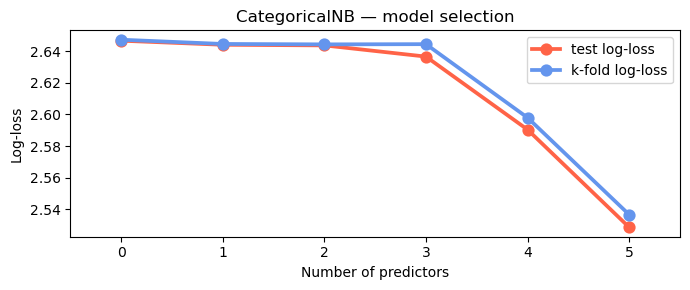

In [15]:
plt.rcParams['figure.figsize'] = [7, 3]
plt.rcParams['figure.autolayout'] = True
sns.pointplot(data=result_df, x=result_df.index, y='test_ll',  color='tomato',         label='test log-loss')
sns.pointplot(data=result_df, x=result_df.index, y='kf_ll',    color='cornflowerblue', label='k-fold log-loss')
plt.xlabel('Number of predictors')
plt.ylabel('Log-loss')
plt.title('CategoricalNB — model selection')
plt.legend();

### **2.3. Learner 2 — Multinomial Logistic Regression.**

We evaluate logistic regression (i) without and (ii) with interaction terms between `pddistrict` and `intersection`.

In [12]:
# logistic regression w/o interaction terms 

learner = LogisticRegression(max_iter=1000)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'x', 'y', 'intersection'],
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=False,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 2.5953  |  k-fold accuracy: 0.2218
Test   log-loss : 2.5953  |  test   accuracy: 0.2215


{'kf_ll': np.float64(2.5952877632356652),
 'kf_acc': np.float64(0.22179468756113374),
 'test_ll': 2.595252220241222,
 'test_acc': 0.22150213700159171,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 21, 21, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[6.03613166e-03, 1.13358375e-01, 1.22172620e-03, ...,
         4.92047215e-02, 3.93696962e-02, 1.12051098e-02],
        [1.87037377e-03, 6.26027839e-02, 2.29000732e-04, ...,
         2.58224708e-02, 8.13654918e-02, 8.80011552e-03],
        [1.78436583e-03, 6.16748113e-02, 2.39735105e-04, ...,
         2.94289293e-02, 7.52144485e-02, 8.21650332e-03],
        ...,
        [6.39032823e-04, 6.36234662e-02, 4.47071997e-04, ...,
         4.40223000e-02, 4.38364393e-02, 5.42633274e-03],
        [4.91593282e-04, 4.60490958e-02, 4.84101647e-05, ...,
         8.63560463e-02, 5.18453469e-02, 8.21118746e-03],
        [4.91593282e-04, 4.60490958e-02, 4.84101647e-05, ...,
   

In [13]:
# logistic regression with interaction terms

learner = LogisticRegression(max_iter=1000)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'x', 'y', 'intersection'],
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=True,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 2.5510  |  k-fold accuracy: 0.2303
Test   log-loss : 2.5501  |  test   accuracy: 0.2310


{'kf_ll': np.float64(2.551003597216596),
 'kf_acc': np.float64(0.23033890544768007),
 'test_ll': 2.5500918804346786,
 'test_acc': 0.23103820406443182,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 21, 21, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[4.31582673e-03, 1.17123278e-01, 1.47804438e-03, ...,
         7.06213942e-02, 3.43527430e-02, 1.04978416e-02],
        [2.21073177e-03, 6.59609330e-02, 1.41490752e-04, ...,
         2.35474974e-02, 6.68709905e-02, 8.93547792e-03],
        [1.90554379e-03, 6.32762400e-02, 1.39857021e-04, ...,
         2.53485512e-02, 6.51488827e-02, 7.78897181e-03],
        ...,
        [9.98625888e-04, 6.59810149e-02, 4.79776305e-04, ...,
         6.55086265e-02, 3.12994454e-02, 5.91659648e-03],
        [4.77170778e-04, 4.57714946e-02, 2.98893205e-05, ...,
         8.90178362e-02, 5.87870014e-02, 8.69073217e-03],
        [4.77170778e-04, 4.57714946e-02, 2.98893205e-05, ...,
   

In [14]:
# greedy forward selection to identify the optimal predictor subset for logistic regression

lr_candidate_features = ['hour', 'day_of_week', 'month', 'year', 'day', 
                          'x', 'y', 'intersection', 'block', 'dt_numeric']

learner = LogisticRegression(max_iter=1000)

result_lst = [model_validation(learner=learner,
                               k=3,
                               nbr_loops=1,
                               selected_predictors=lr_candidate_features[0:m],
                               one_hot_encoding=True,
                               drop_first=True,
                               use_interaction=False,
                               full_preprocessing=True,
                               scores_only=True) for m in np.arange(1, len(lr_candidate_features) + 1)]

In [15]:
result_df_lr = pd.DataFrame.from_dict(result_lst)
result_df_lr

,kf_ll,kf_acc,test_ll,test_acc,predictors
0,2.672626,0.199241,2.672230,0.199099,[hour]
1,2.670984,0.201213,2.670791,0.200585,"[hour, day_of_week]"
2,2.670644,0.201090,2.670473,0.200687,"[hour, day_of_week, month]"
3,2.660349,0.202225,2.660167,0.201488,"[hour, day_of_week, month, year]"
4,2.660116,0.202081,2.659905,0.201485,"[hour, day_of_week, month, year, day]"
5,2.652842,0.202939,2.652751,0.202387,"[hour, day_of_week, month, year, day, x]"
6,2.631918,0.215602,2.631618,0.215380,"[hour, day_of_week, month, year, day, x, y]"
7,2.585073,0.222706,2.584975,0.222356,"[hour, day_of_week, month, year, day, x, y, in..."
8,2.583771,0.222717,2.583546,0.222282,"[hour, day_of_week, month, year, day, x, y, in..."
9,2.583762,0.222759,2.583547,0.222285,"[hour, day_of_week, month, year, day, x, y, in..."


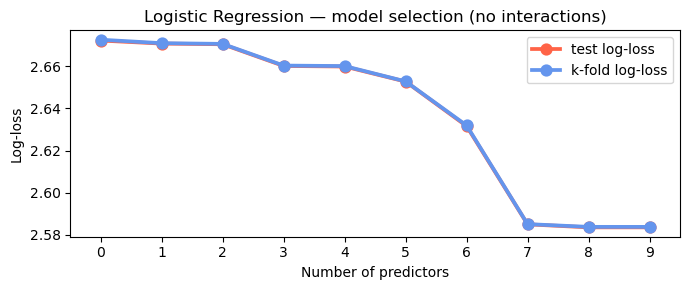

In [16]:
plt.rcParams['figure.figsize'] = [7, 3]
plt.rcParams['figure.autolayout'] = True
sns.pointplot(data=result_df_lr, x=result_df_lr.index, y='test_ll',  color='tomato',         label='test log-loss')
sns.pointplot(data=result_df_lr, x=result_df_lr.index, y='kf_ll',    color='cornflowerblue', label='k-fold log-loss')
plt.xlabel('Number of predictors')
plt.ylabel('Log-loss')
plt.title('Logistic Regression — model selection (no interactions)')
plt.legend();

In [17]:
# evaluate the optimal model without interactions on the test set

best_n_lr = result_df_lr['kf_ll'].idxmin() + 1
best_predictors_lr = lr_candidate_features[:best_n_lr]

learner = LogisticRegression(max_iter=1000)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=best_predictors_lr,
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=False,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 2.5838  |  k-fold accuracy: 0.2228
Test   log-loss : 2.5835  |  test   accuracy: 0.2223


{'kf_ll': np.float64(2.583761655674122),
 'kf_acc': np.float64(0.2227590204464882),
 'test_ll': 2.5835469014355055,
 'test_acc': 0.22228518222174132,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 21, 21, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[6.34146526e-03, 1.10007735e-01, 1.96180035e-03, ...,
         8.45979875e-02, 4.30210670e-02, 9.67882608e-03],
        [1.80492763e-03, 6.25712822e-02, 6.38613781e-04, ...,
         4.21714447e-02, 8.70812528e-02, 7.64686278e-03],
        [1.73910942e-03, 6.17317158e-02, 6.34415527e-04, ...,
         4.84683225e-02, 8.10535316e-02, 7.16458311e-03],
        ...,
        [5.90963850e-04, 5.99980518e-02, 1.51986582e-04, ...,
         1.93762328e-02, 3.67806510e-02, 5.87579034e-03],
        [4.44820829e-04, 4.43371040e-02, 1.64909683e-05, ...,
         3.96592566e-02, 4.57070476e-02, 9.22340807e-03],
        [4.44820829e-04, 4.43371040e-02, 1.64909683e-05, ...,
    

In [18]:
# evaluating the optimal predictor subset with interaction terms
learner = LogisticRegression(max_iter=1000)
model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=best_predictors_lr,
    one_hot_encoding=True,
    drop_first=True,
    use_interaction=True,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 2.5399  |  k-fold accuracy: 0.2330
Test   log-loss : 2.5388  |  test   accuracy: 0.2334


{'kf_ll': np.float64(2.5398944288171106),
 'kf_acc': np.float64(0.2329908214526604),
 'test_ll': 2.538825225840561,
 'test_acc': 0.23335886535323883,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 21, 21, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[4.65013345e-03, 1.12155135e-01, 2.49086349e-03, ...,
         1.24078293e-01, 3.61690660e-02, 8.83295260e-03],
        [2.41516954e-03, 6.76890730e-02, 4.25043826e-04, ...,
         3.91033387e-02, 7.56618615e-02, 7.92010219e-03],
        [2.08801703e-03, 6.44918479e-02, 4.06914263e-04, ...,
         4.28287061e-02, 7.31898536e-02, 6.88071569e-03],
        ...,
        [8.76540962e-04, 6.11813614e-02, 1.45238022e-04, ...,
         2.89278789e-02, 2.65581935e-02, 6.39208816e-03],
        [4.29375316e-04, 4.37913751e-02, 9.84999991e-06, ...,
         3.97968706e-02, 5.12018393e-02, 9.65544797e-03],
        [4.29375316e-04, 4.37913751e-02, 9.84999991e-06, ...,
    

### **2.4. Learner 3 — Random Forest.**

A random forest naturally handles mixed feature types and captures non-linear relationships.

In [25]:
# random forest without one hot encoding 

learner = RandomForestClassifier(n_estimators=200, random_state=12345, n_jobs=-1)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'year', 'x', 'y', 'intersection', 'block'],
    one_hot_encoding=False,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 4.2188  |  k-fold accuracy: 0.2843
Test   log-loss : 4.3741  |  test   accuracy: 0.2951


{'kf_ll': np.float64(4.218842064490439),
 'kf_acc': np.float64(0.2842732112814648),
 'test_ll': 4.374118751920472,
 'test_acc': 0.29507991332401273,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 16, 32, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[0.        , 0.05107143, 0.015     , ..., 0.07      , 0.035     ,
         0.        ],
        [0.        , 0.105     , 0.        , ..., 0.105     , 0.09      ,
         0.        ],
        [0.        , 0.04      , 0.        , ..., 0.015     , 0.11875   ,
         0.        ],
        ...,
        [0.01      , 0.0255    , 0.        , ..., 0.07      , 0.0315    ,
         0.0075    ],
        [0.        , 0.07833333, 0.        , ..., 0.095     , 0.03      ,
         0.0025    ],
        [0.        , 0.07833333, 0.        , ..., 0.095     , 0.03      ,
         0.0025    ]], shape=(351193, 39)),
 'label_enc': LabelEncoder(),
 'predictors': ['hour',
  'day_of_week'

In [26]:
# random forest with one hot encoding

learner = RandomForestClassifier(n_estimators=200, random_state=12345, n_jobs=-1)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=['hour', 'day_of_week', 'month', 'year', 'x', 'y', 'intersection', 'block'],
    one_hot_encoding=True,
    drop_first=False,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 4.2188  |  k-fold accuracy: 0.2843
Test   log-loss : 4.3741  |  test   accuracy: 0.2951


{'kf_ll': np.float64(4.218842064490439),
 'kf_acc': np.float64(0.2842713129954273),
 'test_ll': 4.374118751920472,
 'test_acc': 0.2950827607611769,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 16, 32, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[0.        , 0.05107143, 0.015     , ..., 0.07      , 0.035     ,
         0.        ],
        [0.        , 0.105     , 0.        , ..., 0.105     , 0.09      ,
         0.        ],
        [0.        , 0.04      , 0.        , ..., 0.015     , 0.11875   ,
         0.        ],
        ...,
        [0.01      , 0.0255    , 0.        , ..., 0.07      , 0.0315    ,
         0.0075    ],
        [0.        , 0.07833333, 0.        , ..., 0.095     , 0.03      ,
         0.0025    ],
        [0.        , 0.07833333, 0.        , ..., 0.095     , 0.03      ,
         0.0025    ]], shape=(351193, 39)),
 'label_enc': LabelEncoder(),
 'predictors': ['hour',
  'day_of_week',

In [27]:
# greedy forward selection to identify the optimal predictor subset for random forest

rf_candidate_features = ['x', 'y', 'hour', 'day_of_week', 'month', 'year', 
                          'day', 'intersection', 'block', 'dt_numeric']

learner = RandomForestClassifier(n_estimators=200, random_state=12345, n_jobs=-1)

result_lst = [model_validation(learner=learner,
                               k=3,
                               nbr_loops=1,
                               selected_predictors=rf_candidate_features[0:m],
                               one_hot_encoding=True,
                               drop_first=False,
                               use_interaction=False,
                               full_preprocessing=True,
                               scores_only=True) for m in np.arange(1, len(rf_candidate_features) + 1)]

In [28]:
result_df_rf = pd.DataFrame.from_dict(result_lst)
result_df_rf

,kf_ll,kf_acc,test_ll,test_acc,predictors
0,7.772999,0.269825,6.631310,0.275450,[x]
1,7.127485,0.270537,6.277986,0.275803,"[x, y]"
2,8.777183,0.243010,8.674930,0.254091,"[x, y, hour]"
3,7.206453,0.241448,7.481956,0.254626,"[x, y, hour, day_of_week]"
4,5.423549,0.253285,5.608107,0.266329,"[x, y, hour, day_of_week, month]"
5,4.357916,0.274675,4.520937,0.287423,"[x, y, hour, day_of_week, month, year]"
6,4.022799,0.276693,4.192627,0.290390,"[x, y, hour, day_of_week, month, year, day]"
7,3.957733,0.281781,4.100988,0.295536,"[x, y, hour, day_of_week, month, year, day, in..."
8,4.004635,0.290418,4.146874,0.301808,"[x, y, hour, day_of_week, month, year, day, in..."
9,4.011950,0.286897,4.158358,0.299929,"[x, y, hour, day_of_week, month, year, day, in..."


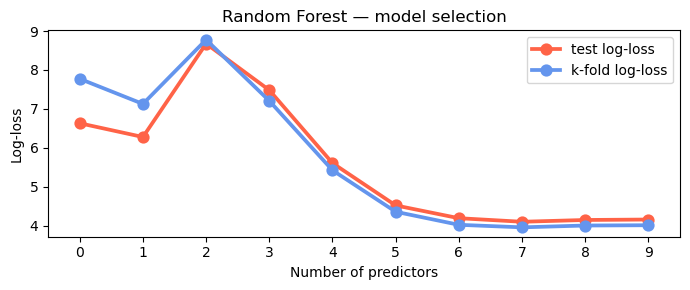

In [29]:
plt.rcParams['figure.figsize'] = [7, 3]
plt.rcParams['figure.autolayout'] = True
sns.pointplot(data=result_df_rf, x=result_df_rf.index, y='test_ll',  color='tomato',         label='test log-loss')
sns.pointplot(data=result_df_rf, x=result_df_rf.index, y='kf_ll',    color='cornflowerblue', label='k-fold log-loss')
plt.xlabel('Number of predictors')
plt.ylabel('Log-loss')
plt.title('Random Forest — model selection')
plt.legend();

In [30]:
# evaluate the optimal random forest on the test set

best_n_rf = result_df_rf['kf_ll'].idxmin() + 1
best_predictors_rf = rf_candidate_features[:best_n_rf]

learner = RandomForestClassifier(n_estimators=200, random_state=12345, n_jobs=-1)

model_validation(
    learner=learner,
    k=3,
    nbr_loops=1,
    selected_predictors=best_predictors_rf,
    one_hot_encoding=True,
    drop_first=False,
    use_interaction=False,
    full_preprocessing=True,
    scores_only=False
)

k-fold log-loss : 3.9577  |  k-fold accuracy: 0.2818
Test   log-loss : 4.1010  |  test   accuracy: 0.2955


{'kf_ll': np.float64(3.957732592305676),
 'kf_acc': np.float64(0.2817807539414072),
 'test_ll': 4.100988249565322,
 'test_acc': 0.2955355032702816,
 'y_test': array([16, 35, 16, ..., 16, 37, 21], shape=(351193,), dtype=int8),
 'y_pred': array([21, 21, 32, ..., 16, 16, 16], shape=(351193,), dtype=int8),
 'y_prob_pred': array([[0.00833333, 0.115     , 0.035     , ..., 0.06666667, 0.0725    ,
         0.        ],
        [0.        , 0.13875   , 0.        , ..., 0.14      , 0.0845    ,
         0.001     ],
        [0.        , 0.06      , 0.        , ..., 0.015     , 0.10166667,
         0.00833333],
        ...,
        [0.01      , 0.01083333, 0.        , ..., 0.05666667, 0.01083333,
         0.02      ],
        [0.        , 0.04666667, 0.        , ..., 0.095     , 0.02366667,
         0.00809524],
        [0.        , 0.04666667, 0.        , ..., 0.095     , 0.02366667,
         0.00809524]], shape=(351193, 39)),
 'label_enc': LabelEncoder(),
 'predictors': ['x',
  'y',
  'hour',
  

## **3. Data Visualization**

In [32]:
# full dataset for visualizations.
X_full = sf_crime(full=True, encoding=False, datetime_index=True)
print('Full dataset shape:', X_full.shape)

Full dataset shape: (877982, 19)


### **3.1. Time-aggregation plots.**

For valid aggregation we restrict to complete periods only (full hours, days, weeks, months, years).

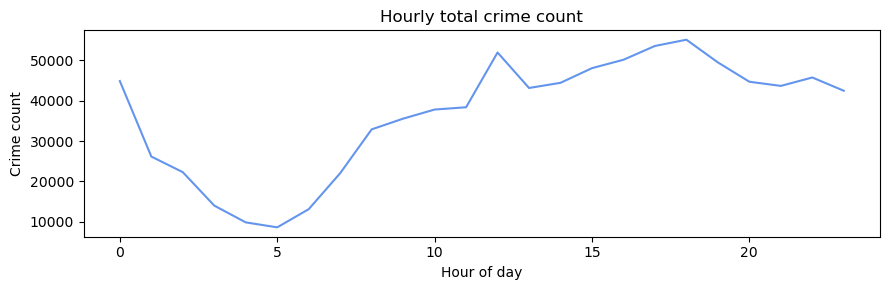

In [34]:
# 1. hourly average number of crimes in a day
hourly = X_full.groupby('hour').size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [9, 3]
plt.rcParams['figure.autolayout'] = True
sns.lineplot(data=hourly, x='hour', y='count', color='cornflowerblue')
plt.title('Hourly total crime count')
plt.xlabel('Hour of day')
plt.ylabel('Crime count');

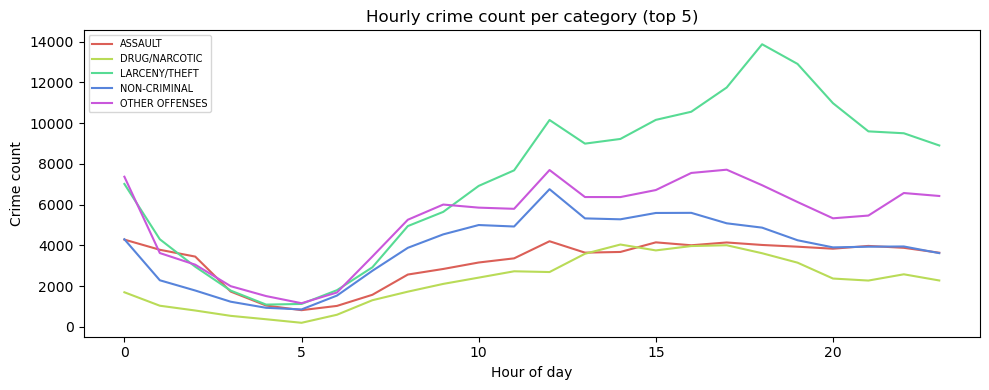

In [35]:
# 2. Hourly average per category
top5_cats = X_full['category'].value_counts().head(5).index.tolist()
hourly_cat = X_full.loc[X_full['category'].isin(top5_cats)]\
    .groupby(['hour', 'category']).size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [10, 4]
sns.lineplot(data=hourly_cat, x='hour', y='count', hue='category', palette='hls')
plt.title('Hourly crime count per category (top 5)')
plt.xlabel('Hour of day')
plt.ylabel('Crime count')
plt.legend(loc='upper left', fontsize=7);

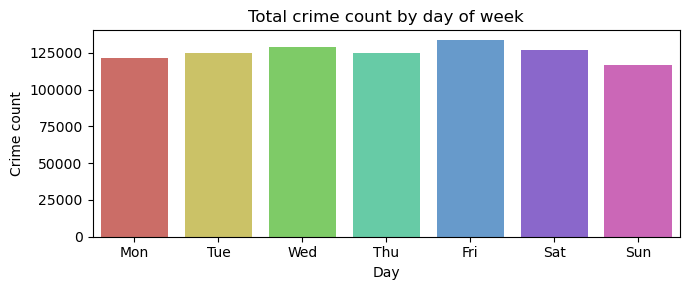

In [36]:
# 3. daily average number of crimes in a week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = X_full.groupby('day_of_week').size().reset_index(name='count')
daily['day_name'] = daily['day_of_week'].map(dict(enumerate(day_names)))

plt.rcParams['figure.figsize'] = [7, 3]
sns.barplot(data=daily, x='day_name', y='count', palette='hls', hue='day_name', legend=False)
plt.title('Total crime count by day of week')
plt.xlabel('Day')
plt.ylabel('Crime count');

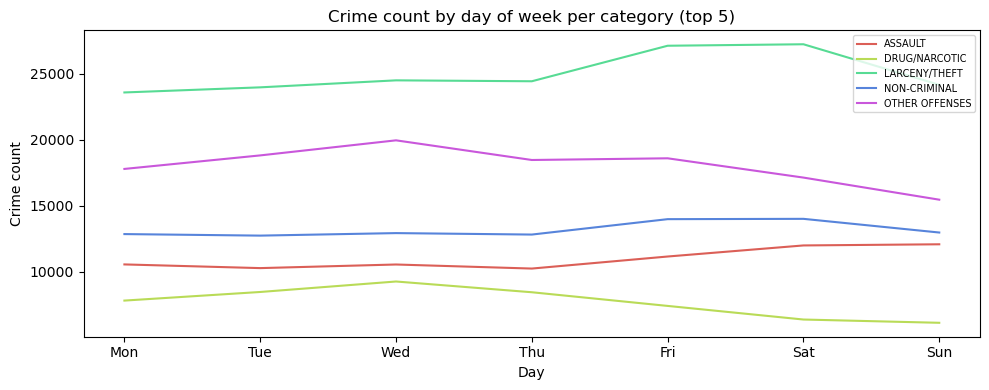

In [37]:
# 4. Daily average per category
daily_cat = X_full.loc[X_full['category'].isin(top5_cats)]\
    .groupby(['day_of_week', 'category']).size().reset_index(name='count')
daily_cat['day_name'] = daily_cat['day_of_week'].map(dict(enumerate(day_names)))

plt.rcParams['figure.figsize'] = [10, 4]
sns.lineplot(data=daily_cat, x='day_name', y='count', hue='category', palette='hls')
plt.title('Crime count by day of week per category (top 5)')
plt.xlabel('Day')
plt.ylabel('Crime count')
plt.legend(fontsize=7);

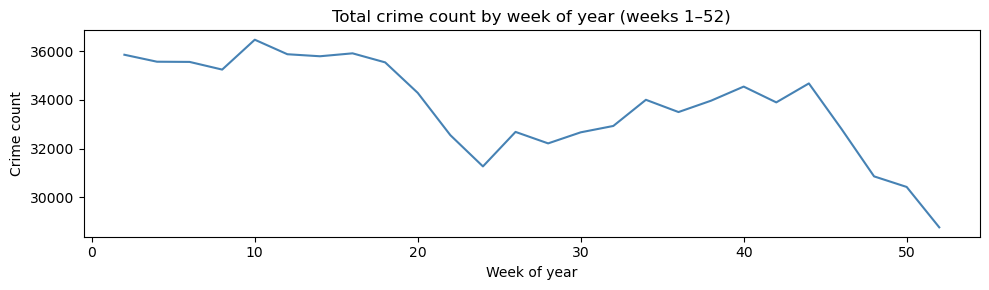

In [38]:
# 5. weekly average: full-week data only (weeks 1-52, exclude partial weeks) 
# keep only years that have data across all 52 weeks.
weekly = X_full.copy()
weekly['week_of_year'] = weekly['week_of_year'].astype(int)
full_week_mask = (weekly['week_of_year'] >= 1) & (weekly['week_of_year'] <= 52)
weekly_agg = weekly.loc[full_week_mask].groupby('week_of_year').size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [10, 3]
sns.lineplot(data=weekly_agg, x='week_of_year', y='count', color='steelblue')
plt.title('Total crime count by week of year (weeks 1–52)')
plt.xlabel('Week of year')
plt.ylabel('Crime count');

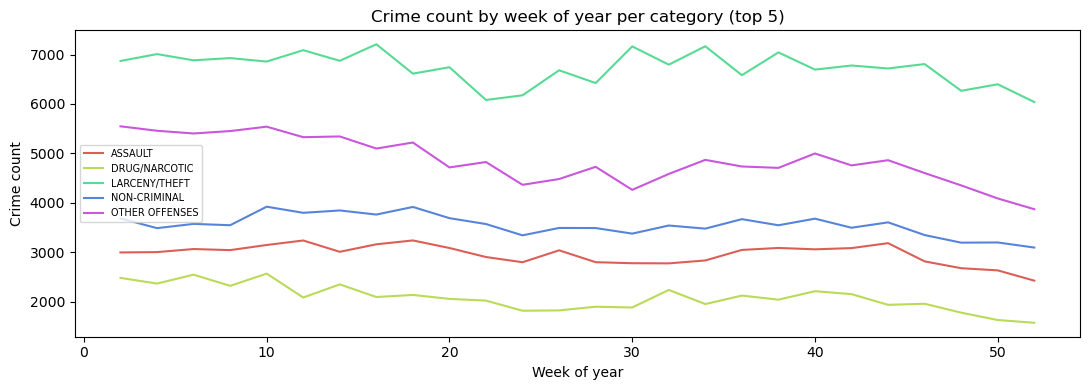

In [39]:
# 6. weekly average per category
weekly_cat = weekly.loc[full_week_mask & weekly['category'].isin(top5_cats)]\
    .groupby(['week_of_year', 'category']).size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [11, 4]
sns.lineplot(data=weekly_cat, x='week_of_year', y='count', hue='category', palette='hls')
plt.title('Crime count by week of year per category (top 5)')
plt.xlabel('Week of year')
plt.ylabel('Crime count')
plt.legend(fontsize=7);

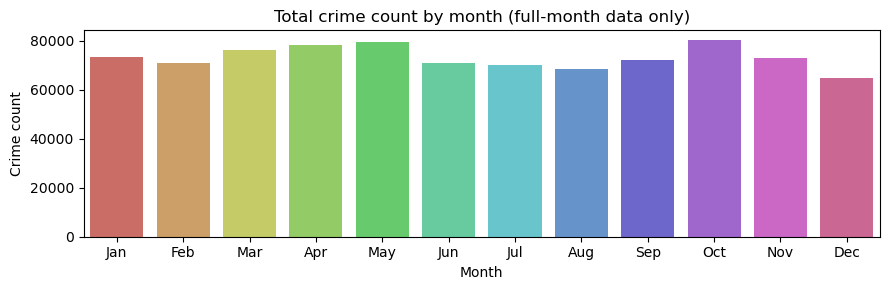

In [40]:
# 7. monthly average: full-month data only
# full month must appear in more than one year 
monthly_agg = X_full.groupby('month').size().reset_index(name='count')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_agg['month_name'] = monthly_agg['month'].map({i+1: m for i, m in enumerate(month_names)})

plt.rcParams['figure.figsize'] = [9, 3]
sns.barplot(data=monthly_agg, x='month_name', y='count', palette='hls', hue='month_name', legend=False)
plt.title('Total crime count by month (full-month data only)')
plt.xlabel('Month')
plt.ylabel('Crime count');

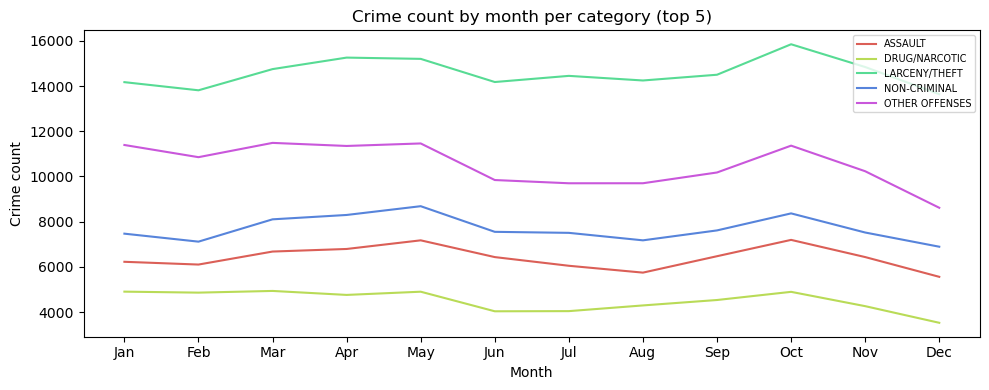

In [41]:
# 8. monthly average per category
monthly_cat = X_full.loc[X_full['category'].isin(top5_cats)]\
    .groupby(['month', 'category']).size().reset_index(name='count')
monthly_cat['month_name'] = monthly_cat['month'].map({i+1: m for i, m in enumerate(month_names)})

plt.rcParams['figure.figsize'] = [10, 4]
sns.lineplot(data=monthly_cat, x='month_name', y='count', hue='category', palette='hls')
plt.title('Crime count by month per category (top 5)')
plt.xlabel('Month')
plt.ylabel('Crime count')
plt.legend(fontsize=7);

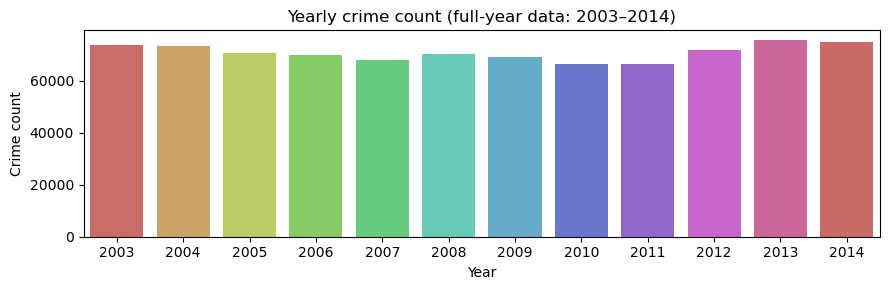

In [42]:
# 9. yearly crime count: full-year data only (2003–2014)
# 2015 is incomplete in the dataset; we exclude it
full_years = X_full.loc[X_full['year'] < 2015]
yearly_agg = full_years.groupby('year').size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [9, 3]
sns.barplot(data=yearly_agg, x='year', y='count', palette='hls', hue='year', legend=False)
plt.title('Yearly crime count (full-year data: 2003–2014)')
plt.xlabel('Year')
plt.ylabel('Crime count');

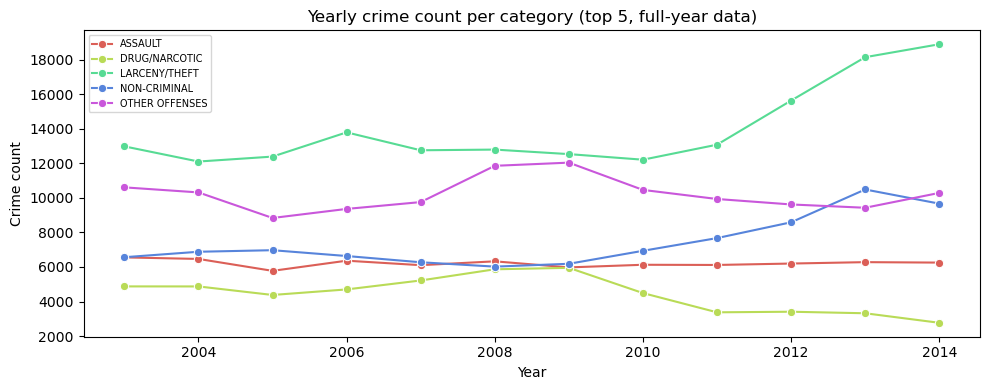

In [43]:
# 10. yearly crime count per category
yearly_cat = full_years.loc[full_years['category'].isin(top5_cats)]\
    .groupby(['year', 'category']).size().reset_index(name='count')

plt.rcParams['figure.figsize'] = [10, 4]
sns.lineplot(data=yearly_cat, x='year', y='count', hue='category', palette='hls', marker='o')
plt.title('Yearly crime count per category (top 5, full-year data)')
plt.xlabel('Year')
plt.ylabel('Crime count')
plt.legend(fontsize=7);

### **3.2. Scatter plot with KDE contours (sample of 50,000).**

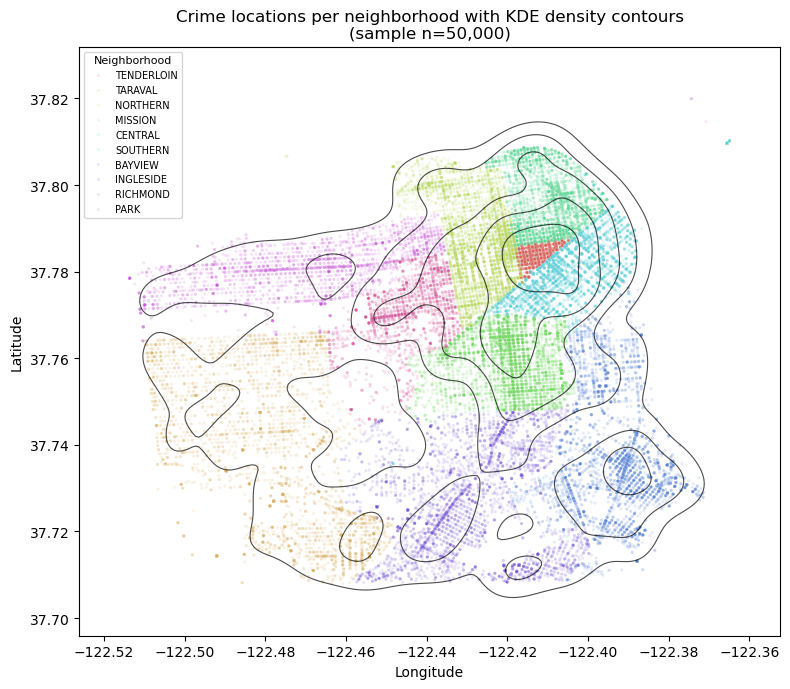

In [45]:
sample_50k = X_full.sample(n=50_000, random_state=12345)

plt.rcParams['figure.figsize'] = [8, 7]
plt.rcParams['figure.autolayout'] = True

sns.scatterplot(data=sample_50k, x='x', y='y', hue='pddistrict',
                legend='full', alpha=0.15, s=5, palette='hls')
sns.kdeplot(data=sample_50k, x='x', y='y',
            levels=6, color='black', linewidths=0.8, alpha=0.7)

plt.title('Crime locations per neighborhood with KDE density contours\n(sample n=50,000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Neighborhood', fontsize=7, title_fontsize=8, loc='upper left');

### **3.3. Stacked histogram-bar: proportion of top-5 crimes per neighborhood (sample of 200,000).**

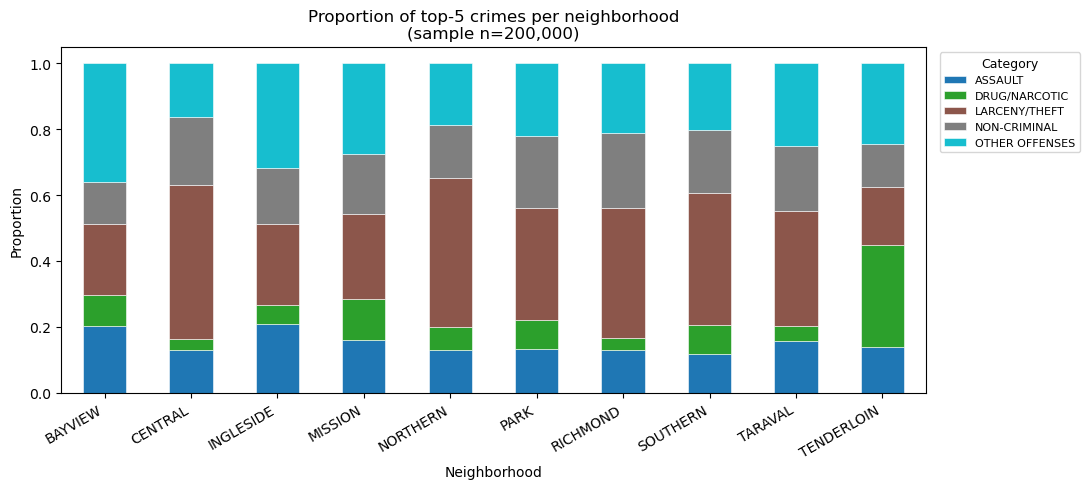

In [46]:
sample_200k = X_full.sample(n=200_000, random_state=12345)

# keep only the 5 most frequent crime categories
top5 = X_full['category'].value_counts().head(5).index.tolist()
sample_top5 = sample_200k.loc[sample_200k['category'].isin(top5)]

# compute proportion of each top-5 category within each neighborhood
prop_df = sample_top5.groupby(['pddistrict', 'category']).size()\
    .unstack(fill_value=0)
prop_df = prop_df.div(prop_df.sum(axis=1), axis=0)  # row-normalize to proportions

plt.rcParams['figure.figsize'] = [11, 5]
plt.rcParams['figure.autolayout'] = True

prop_df.plot(kind='bar', stacked=True,
             colormap='tab10', edgecolor='white', linewidth=0.4)
plt.title('Proportion of top-5 crimes per neighborhood\n(sample n=200,000)')
plt.xlabel('Neighborhood')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Category', fontsize=8, title_fontsize=9, bbox_to_anchor=(1.01, 1));